COVID-19 Clinical trial data analysis

Problem statement:
To analzye the COVID-19 Clinical trial data to
-Understand distribution of trials across phases

-Evaluate trial status outcomes (Completed, Recruiting, Terminated)

-Analyze time trends in trial initiation during the pandemic

-Study relationship between trial phase and completion outcome

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Read the csv

df = pd.read_csv("COVID clinical trials.csv")
df.head

<bound method NDFrame.head of       Rank   NCT Number                                              Title  \
0        1  NCT04785898  Diagnostic Performance of the ID Now™ COVID-19...   
1        2  NCT04595136  Study to Evaluate the Efficacy of COVID19-0001...   
2        3  NCT04395482  Lung CT Scan Analysis of SARS-CoV2 Induced Lun...   
3        4  NCT04416061  The Role of a Private Hospital in Hong Kong Am...   
4        5  NCT04395924         Maternal-foetal Transmission of SARS-Cov-2   
...    ...          ...                                                ...   
5778  5779  NCT04011644  Mobile Health for Alcohol Use Disorders in Cli...   
5779  5780  NCT04681339  Antibiotic Prescription in Children Hospitaliz...   
5780  5781  NCT04740229  Moderate-intensity Flow-based Yoga Effects on ...   
5781  5782  NCT04804917           3-year Follow-up of the Mind My Mind RCT   
5782  5783  NCT04680000  Chronic Pain Management In Primary Care Using ...   

           Acronym                  Status         Study Results  \
0      COVID-IDNow  Active, not recruiting  No Results Available   
1         COVID-19      Not yet recruiting  No Results Available   
2      TAC-COVID19              Recruiting  No Results Available   
3         COVID-19  Active, not recruiting  No Results Available   
4     TMF-COVID-19              Recruiting  No Results Available   
...            ...                     ...                   ...   
5778           NaN              Recruiting  No Results Available   
5779           NaN      Not yet recruiting  No Results Available   
5780           NaN              Recruiting  No Results Available   
5781  MindMyMindFU              Recruiting  No Results Available   
5782           NaN      Not yet recruiting  No Results Available   

                                             Conditions  \
0                                               Covid19   
1                                  SARS-CoV-2 Infection   
2                                               covid19   
3                                                 COVID   
4     Maternal Fetal Infection Transmission|COVID-19...   
...                                                 ...   
5778                      Alcohol Drinking|Telemedicine   
5779  Community Acquired Pneumonia in Children|Antib...   
5780                               Stress|Psychological   
5781  Emotional Problem|Anxiety Disorder of Childhoo...   
5782                                       Chronic Pain   

                                          Interventions  \
0      Diagnostic Test: ID Now™ COVID-19 Screening Test   
1       Drug: Drug COVID19-0001-USR|Drug: normal saline   
2     Other: Lung CT scan analysis in COVID-19 patients   
3             Diagnostic Test: COVID 19 Diagnostic Test   
4     Diagnostic Test: Diagnosis of SARS-Cov2 by RT-...   
...                                                 ...   
5778  Behavioral: A-CHESS self-monitored|Behavioral:...   
5779  Other: Antibiotic treatment|Other: No antibiot...   
5780                                   Behavioral: Yoga   
5781                                                NaN   
5782  Behavioral: Brief Cognitive Behavioral Therapy...   

                                       Outcome Measures  \
0     Evaluate the diagnostic performance of the ID ...   
1     Change on viral load results from baseline aft...   
2     A qualitative analysis of parenchymal lung dam...   
3     Proportion of asymptomatic subjects|Proportion...   
4     COVID-19 by positive PCR in cord blood and / o...   
...                                                 ...   
5778  Number of risky drinking days|Number of patien...   
5779  Antibiotic treatment rates in hospitalized chi...   
5780  Perceived Stress|Task switching paradigm|Digit...   
5781  The child's impact of mental health problems r...   
5782  Defense and Veterans Pain Rating Scale (DVPRS)...   

                                  Sponsor/Collaborators  ...  \
0                 Groupe 

In [6]:
# Understand the dataset

df.shape
df.columns
df.head()

,Rank,NCT Number,Title,Acronym,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,...,Other IDs,Start Date,Primary Completion Date,Completion Date,First Posted,Results First Posted,Last Update Posted,Locations,Study Documents,URL
0,1,NCT04785898,Diagnostic Performance of the ID Now™ COVID-19...,COVID-IDNow,"Active, not recruiting",No Results Available,Covid19,Diagnostic Test: ID Now™ COVID-19 Screening Test,Evaluate the diagnostic performance of the ID ...,Groupe Hospitalier Paris Saint Joseph,...,COVID-IDNow,"November 9, 2020","December 22, 2020","April 30, 2021","March 8, 2021",NaN,"March 8, 2021","Groupe Hospitalier Paris Saint-Joseph, Paris, ...",NaN,https://ClinicalTrials.gov/show/NCT04785898
1,2,NCT04595136,Study to Evaluate the Efficacy of COVID19-0001...,COVID-19,Not yet recruiting,No Results Available,SARS-CoV-2 Infection,Drug: Drug COVID19-0001-USR|Drug: normal saline,Change on viral load results from baseline aft...,United Medical Specialties,...,COVID19-0001-USR,"November 2, 2020","December 15, 2020","January 29, 2021","October 20, 2020",NaN,"October 20, 2020","Cimedical, Barranquilla, Atlantico, Colombia",NaN,https://ClinicalTrials.gov/show/NCT04595136
2,3,NCT04395482,Lung CT Scan Analysis of SARS-CoV2 Induced Lun...,TAC-COVID19,Recruiting,No Results Available,covid19,Other: Lung CT scan analysis in COVID-19 patients,A qualitative analysis of parenchymal lung dam...,University of Milano Bicocca,...,TAC-COVID19,"May 7, 2020","June 15, 2021","June 15, 2021","May 20, 2020",NaN,"November 9, 2020","Ospedale Papa Giovanni XXIII, Bergamo, Italy|P...",NaN,https://ClinicalTrials.gov/show/NCT04395482
3,4,NCT04416061,The Role of a Private Hospital in Hong Kong Am...,COVID-19,"Active, not recruiting",No Results Available,COVID,Diagnostic Test: COVID 19 Diagnostic Test,Proportion of asymptomatic subjects|Proportion...,Hong Kong Sanatorium & Hospital,...,RC-2020-08,"May 25, 2020","July 31, 2020","August 31, 2020","June 4, 2020",NaN,"June 4, 2020","Hong Kong Sanatorium & Hospital, Hong Kong, Ho...",NaN,https://ClinicalTrials.gov/show/NCT04416061
4,5,NCT04395924,Maternal-foetal Transmission of SARS-Cov-2,TMF-COVID-19,Recruiting,No Results Available,Maternal Fetal Infection Transmission|COVID-19...,Diagnostic Test: Diagnosis of SARS-Cov2 by RT-...,COVID-19 by positive PCR in cord blood and / o...,Centre Hospitalier Régional d'Orléans|Centre d...,...,CHRO-2020-10,"May 5, 2020",May 2021,May 2021,"May 20, 2020",NaN,"June 4, 2020","CHR Orléans, Orléans, France",NaN,https://ClinicalTrials.gov/show/NCT04395924


In [7]:
# Missing Value Analysis

df.isnull().sum().sort_values(ascending=False)

,0
Results First Posted,5747
Study Documents,5601
Acronym,3303
Phases,2461
Interventions,886
Locations,585
Primary Completion Date,36
Completion Date,36
Study Designs,35
Outcome Measures,35


In [11]:
# Data Cleaning and Preprocessing

# Remove duplicate trials
df = df.drop_duplicates()

# Handle missing categorical values
df["Phases"] = df["Phases"].fillna("Not Specified")
df["Status"] = df["Status"].fillna("Unknown")

# Convert date columns to datetime
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')
df['Completion Date'] = pd.to_datetime(df['Completion Date'], errors='coerce')

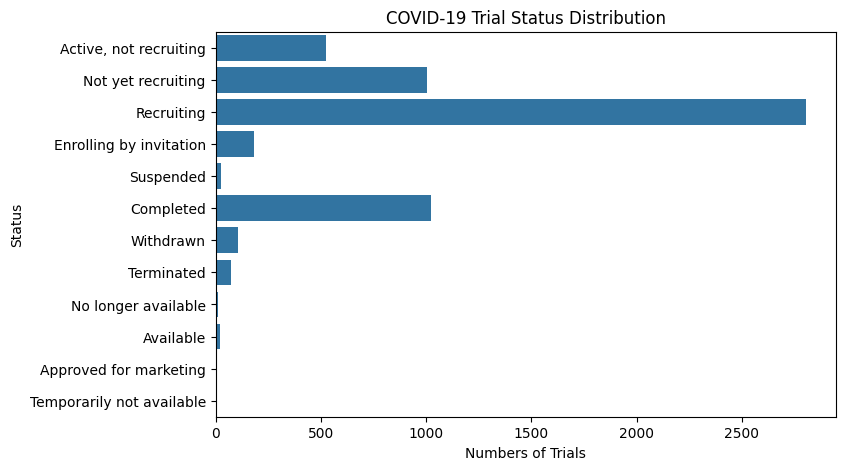

In [15]:
# Exploratory Data Analysis

# Trial status distribution

plt.figure(figsize=(8,5))
sns.countplot(y=df["Status"])
plt.title("COVID-19 Trial Status Distribution")
plt.xlabel("Numbers of Trials")
plt.ylabel("Status")
plt.show()

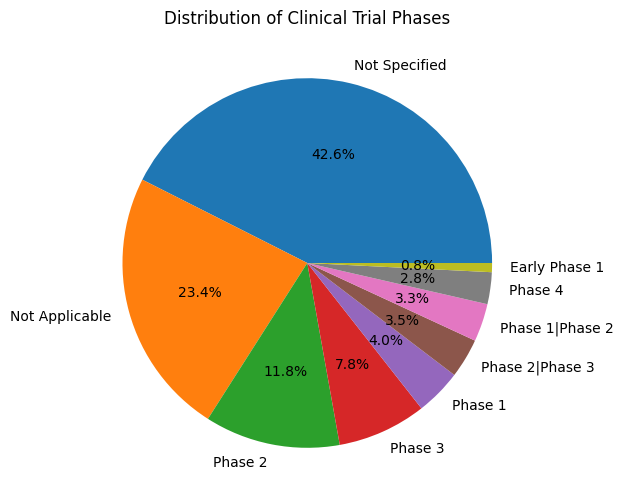

In [18]:
# Trial Phase Distribution

phase_counts = df["Phases"].value_counts()

plt.figure(figsize=(6,6))
phase_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribution of Clinical Trial Phases")
plt.ylabel("")
plt.show()


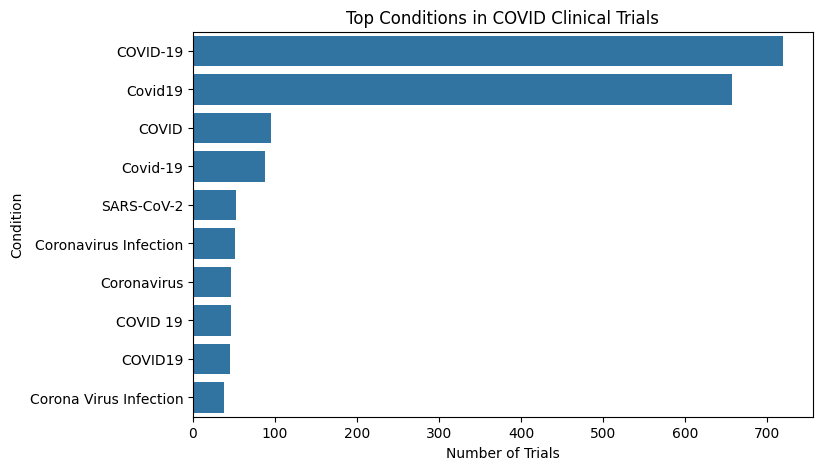

In [19]:
# Top Conditions Studies

top_conditions = df['Conditions'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_conditions.values, y=top_conditions.index)
plt.title("Top Conditions in COVID Clinical Trials")
plt.xlabel("Number of Trials")
plt.ylabel("Condition")
plt.show()


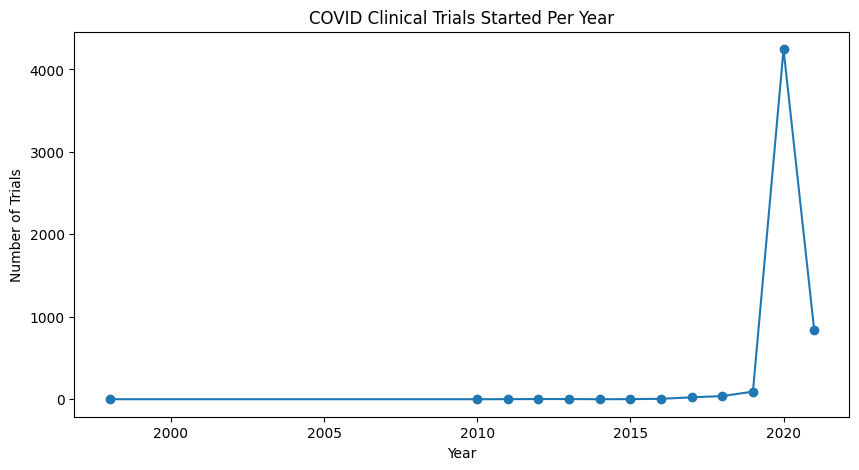

In [20]:
# Time-Based Trend Analysis

df['Start Year'] = df['Start Date'].dt.year
yearly_trials = df['Start Year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
yearly_trials.plot(marker='o')
plt.title("COVID Clinical Trials Started Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Trials")
plt.show()


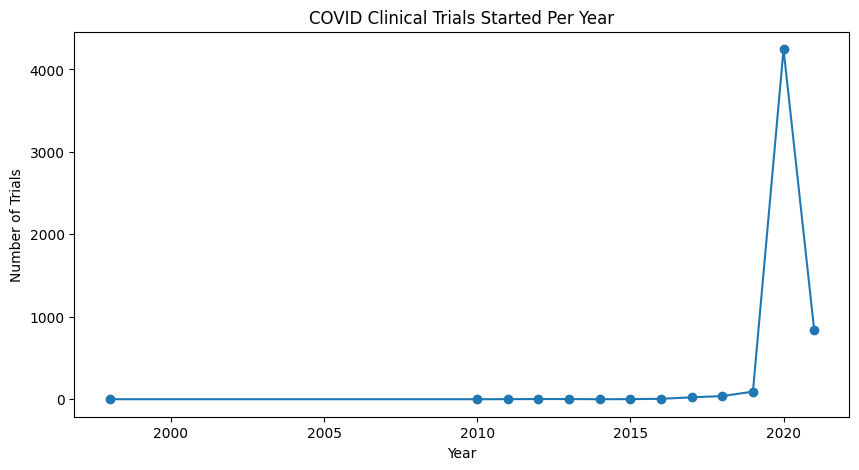

In [21]:
# Sponsor Analysis

df['Start Year'] = df['Start Date'].dt.year
yearly_trials = df['Start Year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
yearly_trials.plot(marker='o')
plt.title("COVID Clinical Trials Started Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Trials")
plt.show()


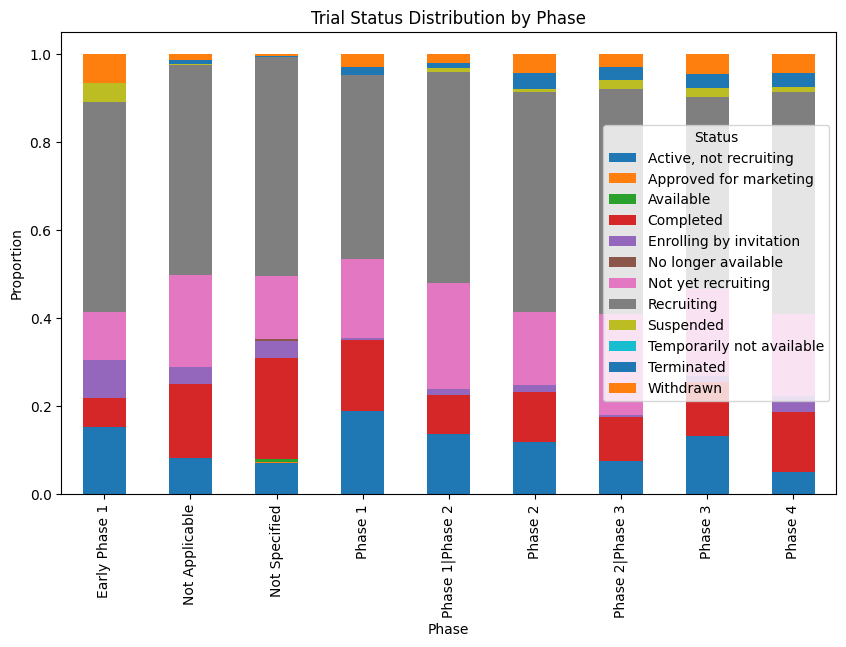

In [24]:
# Outcome vs Sponsor Analysis

phase_status = (
    df.groupby('Phases')['Status']
    .value_counts(normalize=True)
    .unstack()
)

phase_status.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Trial Status Distribution by Phase")
plt.xlabel("Phase")
plt.ylabel("Proportion")
plt.show()




Summary

-Majority of COVID-19 trials were Phase 2 & Phase 3

-Most trials reached completion or active recruitment

-Peak trial activity occurred during 2020–2021

-Later-phase trials had higher success rate